In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import label, opening, closing, square
from skimage.measure import regionprops
from PIL import Image

In [ ]:
# Fungsi untuk menampilkan gambar dengan subplot
def display_images(images, titles=None, cmap='gray'):
    num_images = len(images)
    plt.figure(figsize=(5 * num_images, 5))
    for i, img in enumerate(images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img, cmap=cmap)
        plt.title(titles[i] if titles else f"Image {i + 1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Membaca gambar dan mengonversinya ke grayscale (numpy array)
image_files = ['depan.jpeg', 'belakang.jpeg', 'acak.jpeg']
images = [np.array(Image.open(img).convert('L')) for img in image_files]
titles = ['Koin Depan', 'Koin Belakang', 'Koin Acak']

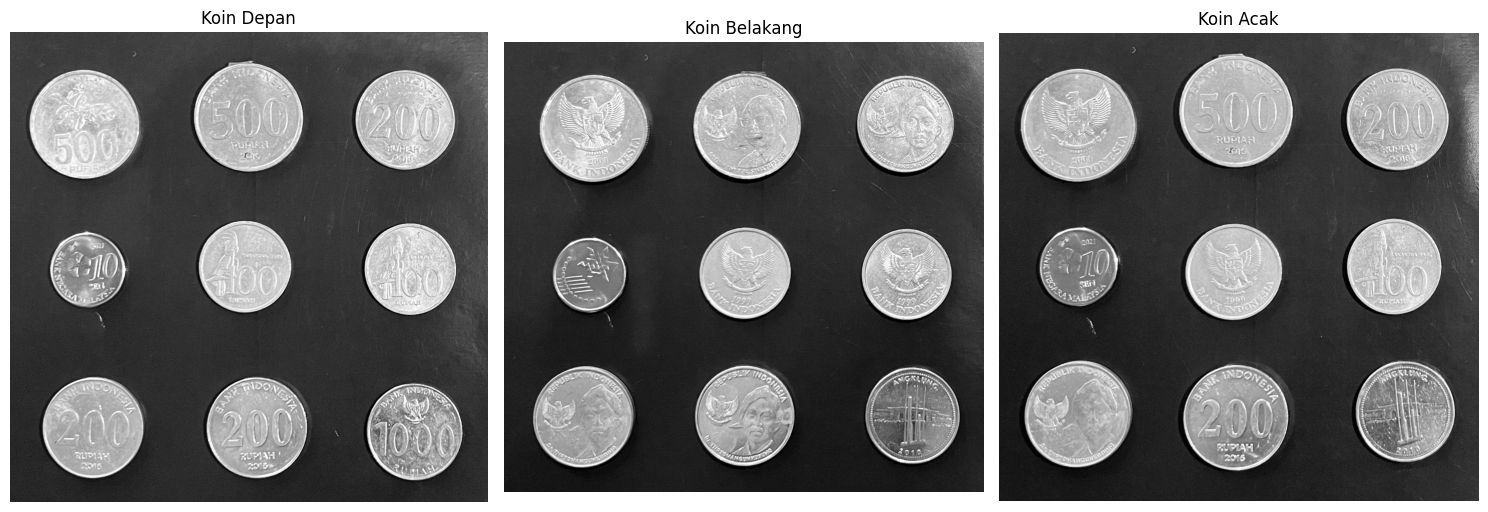

In [ ]:
# Menampilkan gambar asli
display_images(images, titles)

In [ ]:
# Otsu Thresholding untuk setiap gambar
thresholds = [threshold_otsu(img) for img in images]
binary_images = [img > th for img, th in zip(images, thresholds)]

Threshold Otsu untuk setiap gambar:
Koin Depan: 124
Koin Belakang: 114
Koin Acak: 114


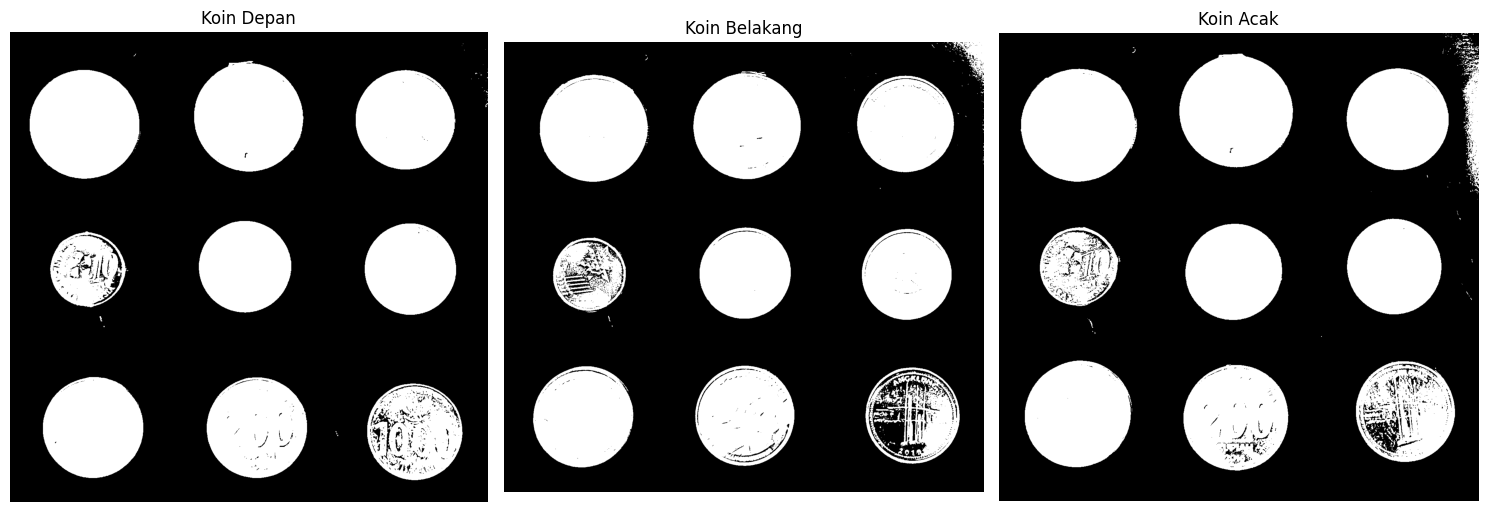

In [ ]:
# Menampilkan hasil threshold
print("Threshold Otsu untuk setiap gambar:")
for i, th in enumerate(thresholds):
    print(f"{titles[i]}: {th}")

display_images(binary_images, titles, cmap='gray')

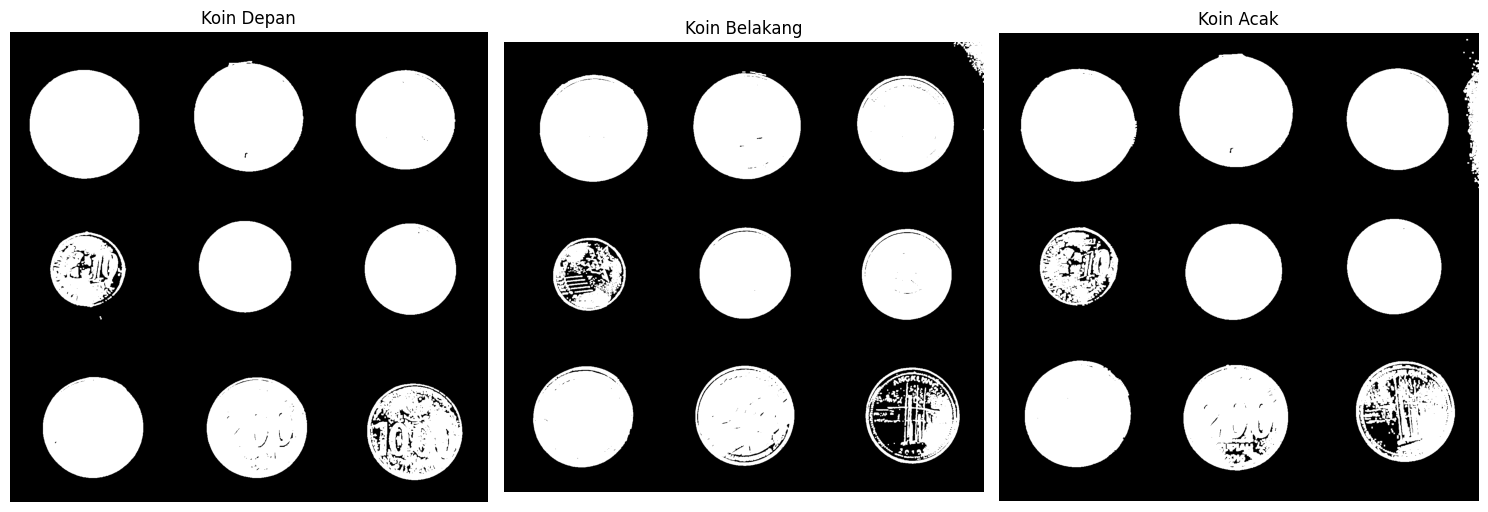

In [ ]:
# Operasi morfologi (Opening) untuk menghilangkan noise kecil
opened_images = [opening(b_img, square(4)) for b_img in binary_images]

display_images(opened_images, titles, cmap='gray')

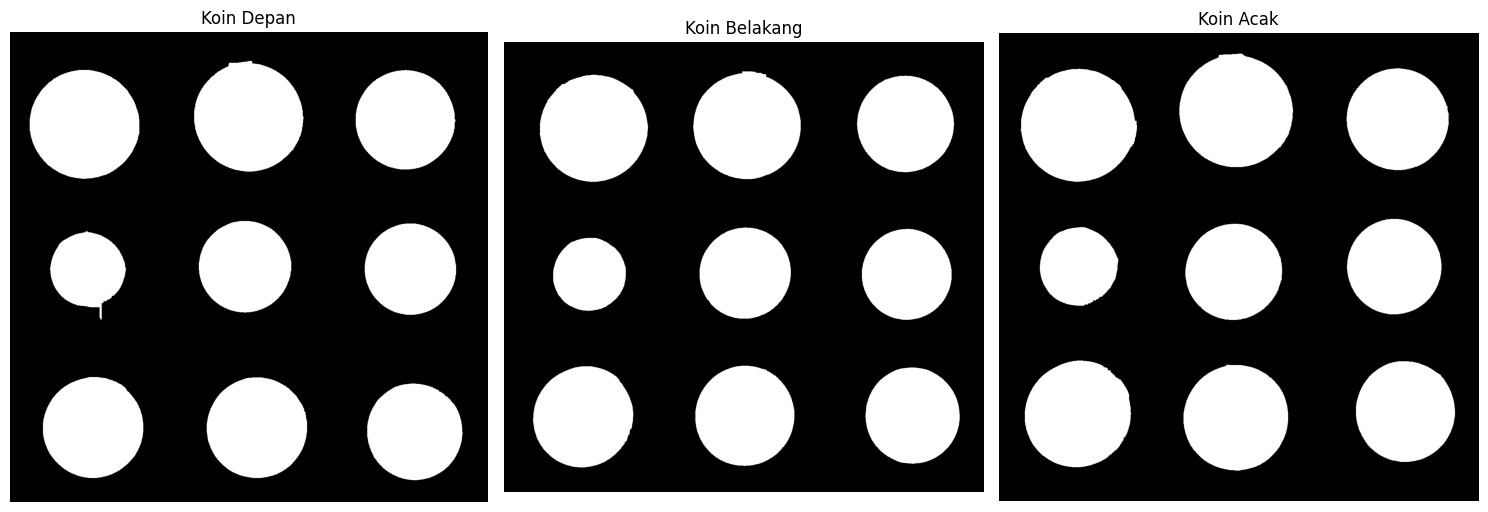

In [ ]:
# Operasi morfologi (Closing) untuk menyempurnakan hasil segmentasi
closing_kernels = [square(60), square(70), square(45)]  # Kernel berbeda untuk setiap gambar
final_images = [
    clear_border(closing(o_img, kernel))
    for o_img, kernel in zip(opened_images, closing_kernels)
]

display_images(final_images, titles, cmap='gray')

In [ ]:
# Labeling objek
labeled_images = [measure.label(img) for img in final_images]

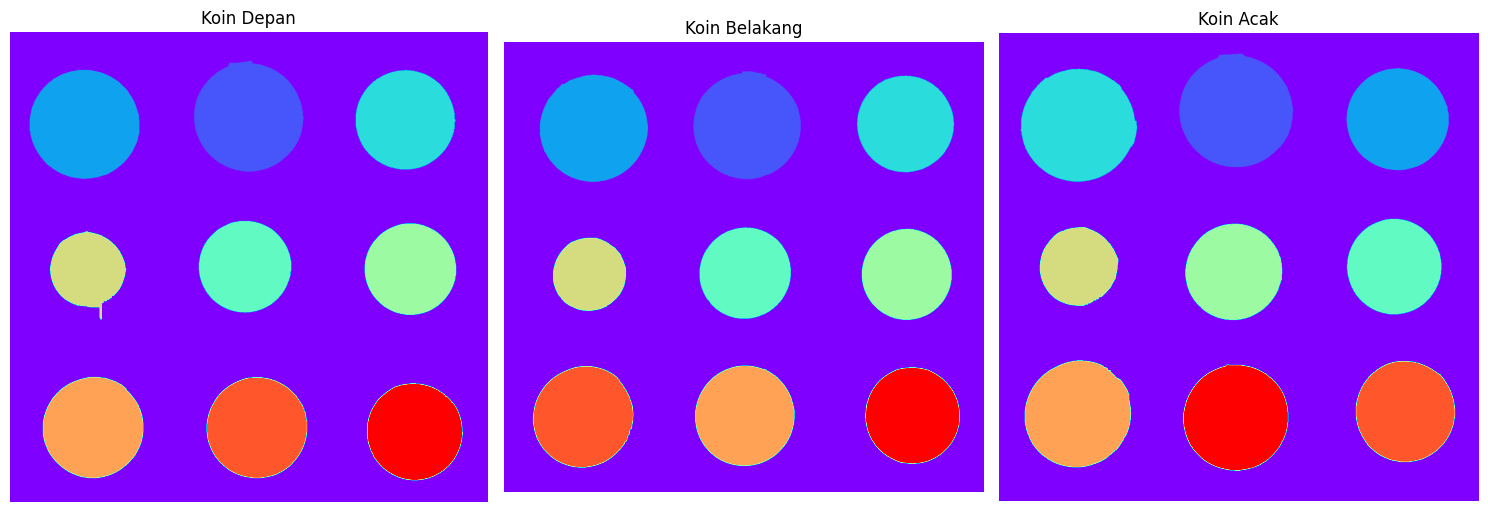

In [ ]:
# Menampilkan gambar dengan label
display_images(labeled_images, titles, cmap='rainbow')

In [ ]:
# Menghitung jumlah objek pada setiap gambar
print("\nJumlah koin yang terdeteksi:")
for i, labels in enumerate(labeled_images):
    regions = regionprops(labels)
    count = len([region for region in regions if region.area > 100])
    print(f"{titles[i]}: {count} koin")


Jumlah koin yang terdeteksi:
Koin Depan: 9 koin
Koin Belakang: 9 koin
Koin Acak: 9 koin


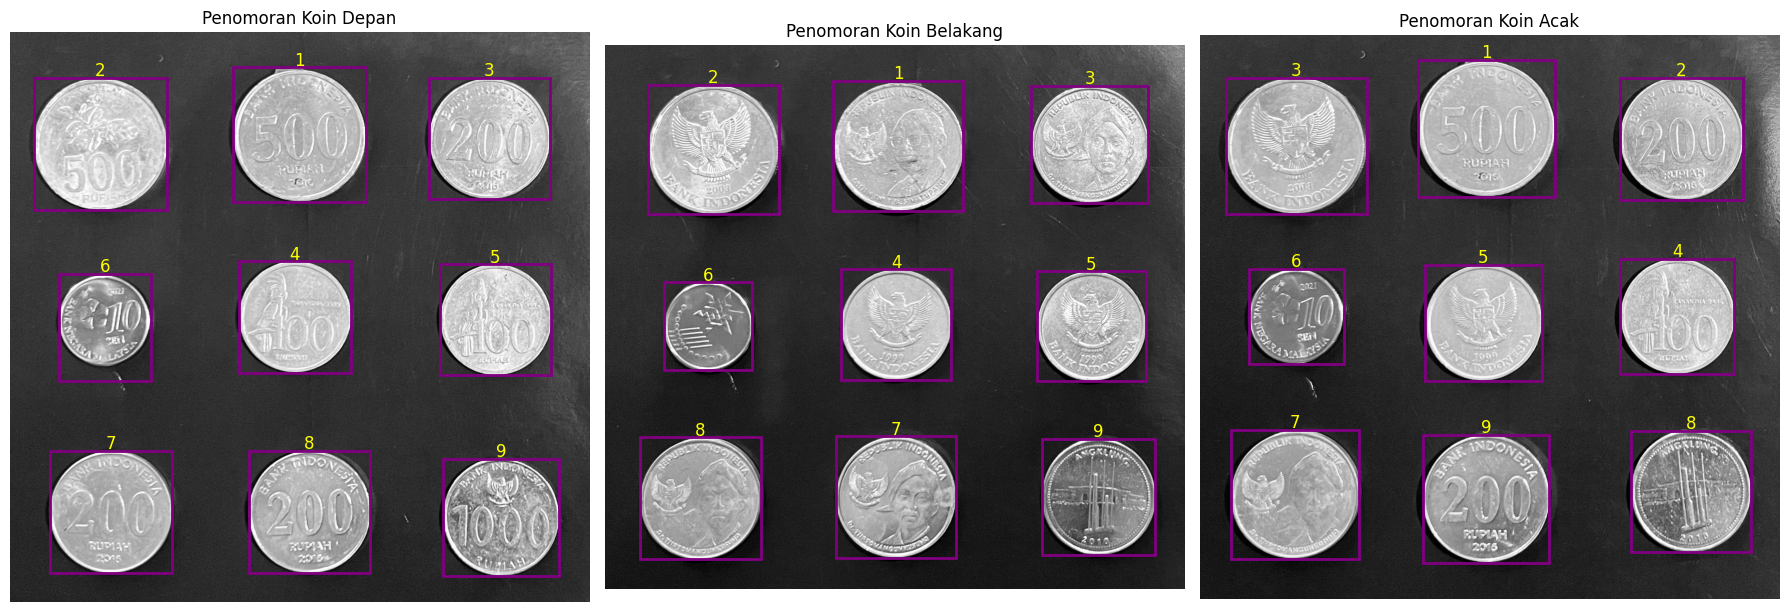

In [ ]:
# Visualisasi bounding box dan penomoran koin
fig, axes = plt.subplots(1, len(images), figsize=(18, 6))

for i, (original_img, labeled_img) in enumerate(zip(images, labeled_images)):
    axes[i].imshow(original_img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Penomoran {titles[i]}")

    regions = regionprops(labeled_img)
    bounding_boxes = [
        region.bbox for region in regions if region.area > 100
    ]
    for j, box in enumerate(bounding_boxes, start=1):
        ymin, xmin, ymax, xmax = box
        axes[i].add_patch(
            plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                          edgecolor='purple', facecolor='none', linewidth=2)
        )
        axes[i].text(
            xmin + (xmax - xmin) / 2,
            ymin - 5,
            str(j),
            color='yellow',
            fontsize=12,
            ha='center'
        )

plt.tight_layout()
plt.show()